In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from scipy.stats import kurtosis, skew
from tqdm.notebook import tqdm

DATA_DIR = Path("/mnt/c/Users/enfan/Documents/StageUmons/IMS/2nd_test/")
FS = 20000  # Hz
files = sorted(os.listdir(DATA_DIR))
files_clean = files[:-2]  # On exclut les 2 derniers (machine éteinte)
print(f"{len(files_clean)} fichiers à traiter")

982 fichiers à traiter


In [2]:
def compute_fft(signal, fs):
    N = len(signal)
    fft_mag = np.abs(np.fft.rfft(signal)) * 2 / N
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag

def energy_in_band(freqs, fft_mag, f_low, f_high):
    mask = (freqs >= f_low) & (freqs <= f_high)
    return np.sum(fft_mag[mask] ** 2)

# Bandes spectrales justifiées par notre analyse exploratoire
BANDS = {
    'band_0_100':    (0, 100),       # Rotation + cage
    'band_200_260':  (200, 260),     # BPFO fondamental (~230 Hz réel)
    'band_440_500':  (440, 500),     # 2×BPFO
    'band_670_730':  (670, 730),     # 3×BPFO
    'band_900_950':  (900, 950),     # 4×BPFO
    'band_970_1010': (970, 1010),    # Résonance structurelle (~985 Hz)
    'band_HF':       (1100, 10000),  # Énergie HF (feature N°1)
}

def extract_features(signal, fs):
    """Extrait un vecteur de features d'un signal 1D (1 roulement, 1 fichier)."""
    feats = {}
    # --- Features temporelles ---
    feats['rms']      = np.sqrt(np.mean(signal**2))
    feats['peak']     = np.max(np.abs(signal))
    feats['p2p']      = np.max(signal) - np.min(signal)
    feats['kurtosis'] = kurtosis(signal)          # Détecte les chocs (gaussien=0 avec scipy)
    feats['skew']     = skew(signal)
    feats['crest']    = feats['peak'] / (feats['rms'] + 1e-12)  # Facteur de crête
    feats['std']      = np.std(signal)
    # --- Features fréquentielles (énergie par bande) ---
    freqs, fft_mag = compute_fft(signal, fs)
    for band_name, (f_low, f_high) in BANDS.items():
        feats[band_name] = energy_in_band(freqs, fft_mag, f_low, f_high)
    return feats

# Test sur un fichier
test_signal = np.loadtxt(DATA_DIR / files_clean[0])[:, 0]  # Bearing 1
test_feats = extract_features(test_signal, FS)
print("Features extraites pour le 1er fichier (Bearing 1) :")
for k, v in test_feats.items():
    print(f"  {k:<15} = {v:.6f}")
print(f"\nNombre de features : {len(test_feats)}")

Features extraites pour le 1er fichier (Bearing 1) :
  rms             = 0.074179
  peak            = 0.454000
  p2p             = 0.840000
  kurtosis        = 0.628763
  skew            = 0.083993
  crest           = 6.120331
  std             = 0.073475
  band_0_100      = 0.000853
  band_200_260    = 0.000088
  band_440_500    = 0.000095
  band_670_730    = 0.000020
  band_900_950    = 0.000063
  band_970_1010   = 0.002024
  band_HF         = 0.007395

Nombre de features : 14


In [3]:
# Extraire les features pour TOUS les fichiers, sur Bearing 1
print("Extraction des features sur 982 fichiers (~3-5 min)...")

feature_list = []
for fname in tqdm(files_clean):
    signal = np.loadtxt(DATA_DIR / fname)[:, 0]  # Bearing 1
    feats = extract_features(signal, FS)
    feature_list.append(feats)

# Construire un DataFrame propre
df = pd.DataFrame(feature_list)
df.index.name = 'file_index'

print(f"\nShape : {df.shape}")
print(df.head())
print(f"\nNaN présents : {df.isna().sum().sum()}")

Extraction des features sur 982 fichiers (~3-5 min)...


  0%|          | 0/982 [00:00<?, ?it/s]


Shape : (982, 14)
                 rms   peak    p2p  kurtosis      skew     crest       std  \
file_index                                                                   
0           0.074179  0.454  0.840  0.628763  0.083993  6.120331  0.073475   
1           0.075382  0.388  0.757  0.648291  0.052142  5.147086  0.075338   
2           0.076230  0.503  0.903  0.513475  0.032808  6.598472  0.076189   
3           0.078724  0.608  1.184  1.157953  0.041486  7.723217  0.078691   
4           0.078474  0.391  0.782  0.603177  0.028224  4.982524  0.078437   

            band_0_100  band_200_260  band_440_500  band_670_730  \
file_index                                                         
0             0.000853      0.000088      0.000095      0.000020   
1             0.000481      0.000123      0.000104      0.000032   
2             0.000547      0.000082      0.000116      0.000037   
3             0.000503      0.000071      0.000096      0.000024   
4             0.000479    

In [4]:
df.to_csv('features_set2_bearing1.csv')
print("Features sauvegardées dans features_set2_bearing1.csv")
print("→ Plus besoin de recalculer à chaque fois !")

Features sauvegardées dans features_set2_bearing1.csv
→ Plus besoin de recalculer à chaque fois !


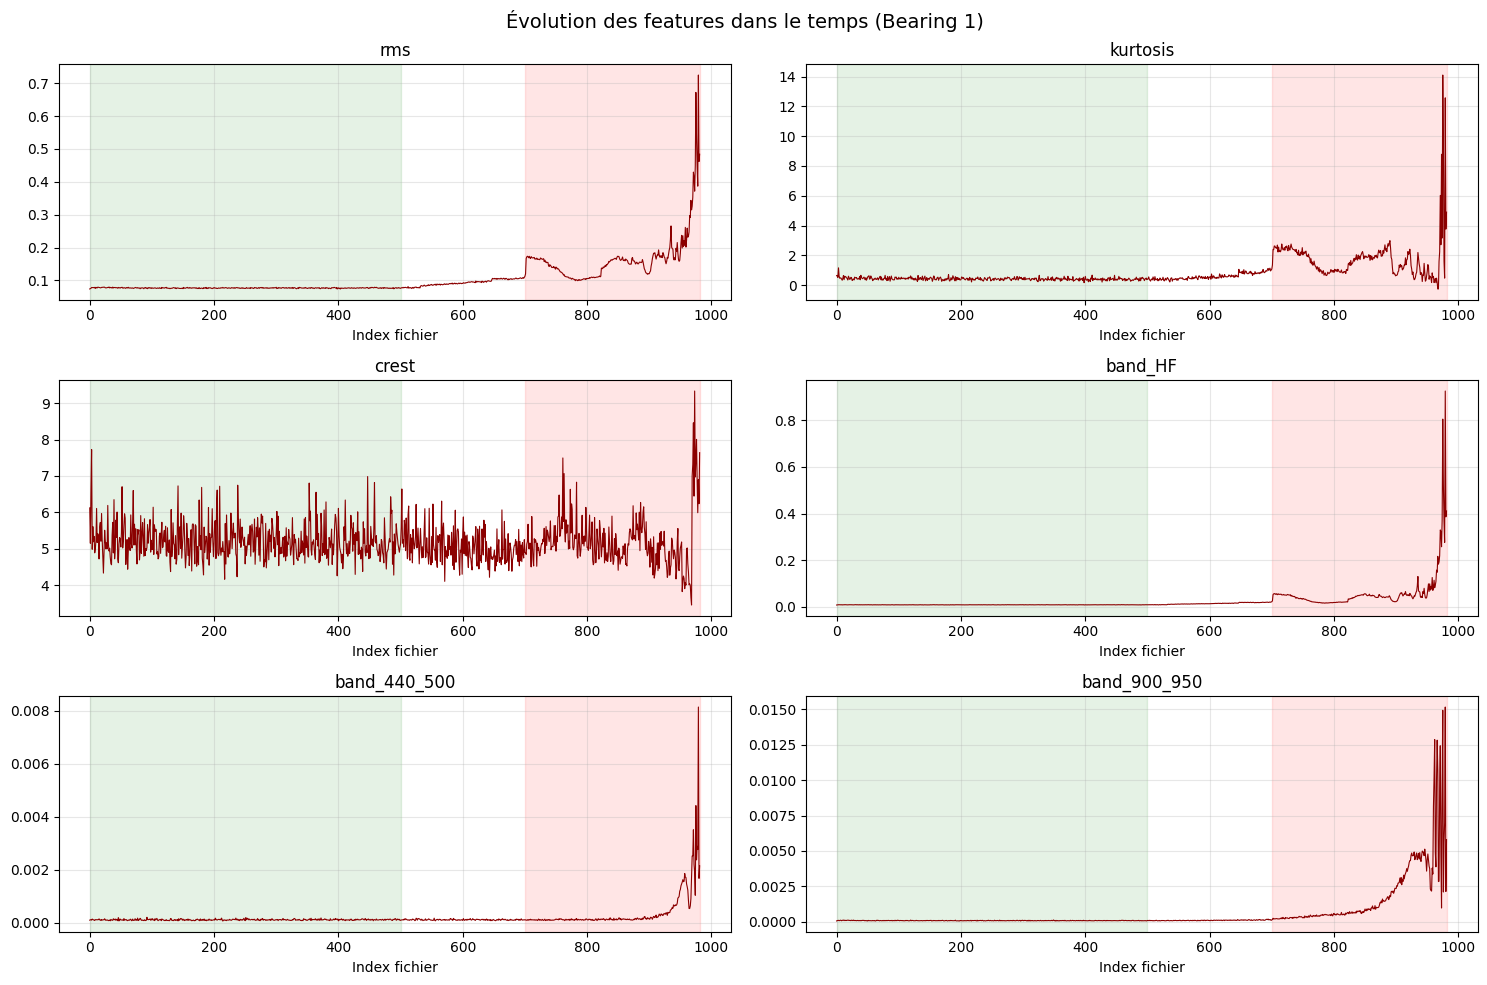

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
features_to_plot = ['rms', 'kurtosis', 'crest', 'band_HF', 'band_440_500', 'band_900_950']

for ax, feat in zip(axes.flat, features_to_plot):
    ax.plot(df[feat].values, linewidth=0.8, color='darkred')
    ax.axvspan(0, 500, alpha=0.1, color='green')
    ax.axvspan(700, len(df), alpha=0.1, color='red')
    ax.set_title(feat)
    ax.set_xlabel('Index fichier')
    ax.grid(True, alpha=0.3)

plt.suptitle("Évolution des features dans le temps (Bearing 1)", fontsize=14)
plt.tight_layout()
plt.show()